# T3_01 — Hybrid Transformer + GRU (Close, 1D, full)

Reglas fuente de verdad: `experimentos_v3/readme_experimentos_v3.md` y `experimentos_v3/PLANNING.md`.

Objetivo (Task A): entrenar para predecir **`log_return(t+1)`** y reconstruir **`close(t+1)`** para gráficos y métricas.

Arquitectura: **Transformer Encoder → GRU head → regresión**.

## 1) Imports

In [1]:
from __future__ import annotations

import json
import math
import random
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset


def to_relative(path: Path, root: Path) -> str:
    try:
        return str(path.relative_to(root))
    except ValueError:
        return str(path)


def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for p in [start, *start.parents]:
        if (p / "data").exists() and (p / "experimentos_v3").exists():
            return p
    raise FileNotFoundError("No se encontró el root del proyecto (esperado: carpetas 'data' y 'experimentos_v3')")


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


## 2) Paths y configuración

In [2]:
PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"

DATASET_NAME = "full"
TASK_NAME = "close"
MODEL_NAME = "T3_01_transformer_gru"

DATASET_PATH = DATA_DIR / f"btc_1d_features__{DATASET_NAME}.csv"
SPLIT_PATH = DATA_DIR / "_splits" / "splits_1d_walkforward_v3_holdout_from_2025_06.json"

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LOOKBACK = 60
D_MODEL = 64
N_HEADS = 4
N_LAYERS = 3
FF_DIM = 128
DROPOUT = 0.2

GRU_HIDDEN = 64
GRU_LAYERS = 1
GRU_DROPOUT = 0.0
GRU_BIDIRECTIONAL = False

LR = 1e-4
WEIGHT_DECAY = 5e-4
BATCH_SIZE = 256
MAX_EPOCHS = 60
MIN_EPOCHS = 10
PATIENCE = 12
MIN_DELTA = 1e-4

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = DATA_DIR / "_experiments" / TASK_NAME / MODEL_NAME / DATASET_NAME / RUN_ID
OUT_DIR.mkdir(parents=True, exist_ok=True)

set_seed(SEED)

{
    "dataset_path": to_relative(DATASET_PATH, PROJECT_ROOT),
    "split_path": to_relative(SPLIT_PATH, PROJECT_ROOT),
    "out_dir": to_relative(OUT_DIR, PROJECT_ROOT),
    "device": str(DEVICE),
    "seed": SEED,
    "lookback": LOOKBACK,
    "d_model": D_MODEL,
    "n_heads": N_HEADS,
    "n_layers": N_LAYERS,
    "ff_dim": FF_DIM,
    "dropout": DROPOUT,
    "gru_hidden": GRU_HIDDEN,
    "gru_layers": GRU_LAYERS,
    "gru_dropout": GRU_DROPOUT,
    "gru_bidirectional": GRU_BIDIRECTIONAL,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
}

{'dataset_path': 'data/btc_1d_features__full.csv',
 'split_path': 'data/_splits/splits_1d_walkforward_v3_holdout_from_2025_06.json',
 'out_dir': 'data/_experiments/close/T3_01_transformer_gru/full/20260312_014002',
 'device': 'cpu',
 'seed': 42,
 'lookback': 60,
 'd_model': 64,
 'n_heads': 4,
 'n_layers': 3,
 'ff_dim': 128,
 'dropout': 0.2,
 'gru_hidden': 64,
 'gru_layers': 1,
 'gru_dropout': 0.0,
 'gru_bidirectional': False,
 'lr': 0.0001,
 'weight_decay': 0.0005,
 'batch_size': 256,
 'max_epochs': 60,
 'patience': 12}

## 3) Cargar dataset y definir targets (logret/close)

In [3]:
df = pd.read_csv(DATASET_PATH)

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], utc=False)
elif "timestamp" in df.columns:
    df["date"] = pd.to_datetime(df["timestamp"], utc=False)
else:
    raise ValueError("Dataset debe incluir columna 'date' o 'timestamp'")

df = df.sort_values("date").reset_index(drop=True)

required_cols = ["date", "close"]
for c in required_cols:
    if c not in df.columns:
        raise ValueError(f"Falta columna requerida: {c}")

logret_col = None
for candidate in ["log_return", "log_ret", "log_return_close", "log_ret_close"]:
    if candidate in df.columns:
        logret_col = candidate
        break

if logret_col is None:
    close = df["close"].astype(float)
    df["log_return"] = np.log(close / close.shift(1))
    logret_col = "log_return"

df["y_true_logret_t1"] = df[logret_col].shift(-1)
df["y_true_close_t1"] = df["close"].shift(-1)

df = df.dropna(subset=["y_true_logret_t1", "y_true_close_t1"]).copy()

df[["date", "close", logret_col, "y_true_logret_t1", "y_true_close_t1"]].head(3)

,date,close,log_return,y_true_logret_t1,y_true_close_t1
0,2018-02-01 00:00:00+00:00,9010.210912,-0.114383,-0.022444,8810.238040
1,2018-02-02 00:00:00+00:00,8810.238040,-0.022444,0.046096,9225.860000
2,2018-02-03 00:00:00+00:00,9225.860000,0.046096,-0.118935,8191.321445


## 4) Split oficial (walk-forward + holdout)

In [4]:
with open(SPLIT_PATH, "r", encoding="utf-8") as f:
    split = json.load(f)


@dataclass(frozen=True)
class Period:
    name: str
    train_start: pd.Timestamp
    train_end: pd.Timestamp
    val_start: pd.Timestamp
    val_end: pd.Timestamp


def _ts(x: str) -> pd.Timestamp:
    return pd.to_datetime(x)


folds = []
for i, fold in enumerate(split.get("walk_forward_folds", []), start=1):
    folds.append(
        Period(
            name=f"fold_{i}",
            train_start=_ts(fold["train"]["start"]),
            train_end=_ts(fold["train"]["end"]),
            val_start=_ts(fold["val"]["start"]),
            val_end=_ts(fold["val"]["end"]),
        )
    )

final_holdout = split.get("final_holdout")
holdout_start = _ts(final_holdout["start"])
holdout_end = _ts(final_holdout["end"]) if "end" in final_holdout else df["date"].max()

len(folds), folds[0], (holdout_start, holdout_end)

(5,
 Period(name='fold_1', train_start=Timestamp('2014-11-10 00:00:00+0000', tz='UTC'), train_end=Timestamp('2019-12-31 23:59:59+0000', tz='UTC'), val_start=Timestamp('2020-01-01 00:00:00+0000', tz='UTC'), val_end=Timestamp('2020-12-31 23:59:59+0000', tz='UTC')),
 (Timestamp('2025-06-01 00:00:00+0000', tz='UTC'),
  Timestamp('2026-03-10 00:00:00+0000', tz='UTC')))

## 5) Features

In [5]:
ignore = {"date", "timestamp", "y_true_logret_t1", "y_true_close_t1"}
feature_cols = []
for c in df.columns:
    if c in ignore:
        continue
    if pd.api.types.is_numeric_dtype(df[c]):
        feature_cols.append(c)

len(feature_cols), feature_cols[:10]

(47,
 ['open',
  'high',
  'low',
  'close',
  'volume',
  'log_close',
  'log_return',
  'log_volume',
  'rsi_14',
  'sma_8'])

## 6) Métricas (Task A)

In [6]:
def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def smape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    denom = (np.abs(y_true) + np.abs(y_pred))
    denom = np.where(denom == 0, np.nan, denom)
    val = 2.0 * np.abs(y_true - y_pred) / denom
    return float(np.nanmean(val))


def mase(y_true: np.ndarray, y_pred: np.ndarray, y_train: np.ndarray) -> float:
    scale = np.mean(np.abs(y_train[1:] - y_train[:-1]))
    if not np.isfinite(scale) or scale == 0:
        return float("nan")
    return float(mae(y_true, y_pred) / scale)


def compute_metrics_close_level(
    y_true_close: np.ndarray,
    y_pred_close: np.ndarray,
    train_close: np.ndarray,
) -> dict:
    return {
        "MAE": mae(y_true_close, y_pred_close),
        "RMSE": rmse(y_true_close, y_pred_close),
        "sMAPE": smape(y_true_close, y_pred_close),
        "MASE": mase(y_true_close, y_pred_close, train_close),
    }

## 7) Utilidades: slicing, secuencias y modelo

In [7]:
def slice_by_date(df: pd.DataFrame, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    m = (df["date"] >= start) & (df["date"] <= end)
    return df.loc[m].copy()


def build_sequences(
    df_all: pd.DataFrame,
    hist_start: pd.Timestamp,
    hist_end: pd.Timestamp,
    pred_start: pd.Timestamp,
    pred_end: pd.Timestamp,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    lookback: int,
    feature_cols: list[str],
) -> dict[str, np.ndarray]:
    d = slice_by_date(df_all, hist_start, hist_end).reset_index(drop=True)

    X_raw = d[feature_cols].to_numpy(dtype=float)
    y_raw = d[["y_true_logret_t1"]].to_numpy(dtype=float)

    X = x_scaler.transform(X_raw).astype(np.float32)
    y = y_scaler.transform(y_raw).astype(np.float32)

    dates = d["date"].to_numpy()
    close_t = d["close"].to_numpy(dtype=float)
    y_true_logret = d["y_true_logret_t1"].to_numpy(dtype=float)
    y_true_close = d["y_true_close_t1"].to_numpy(dtype=float)

    pred_mask = (d["date"] >= pred_start) & (d["date"] <= pred_end)

    X_seq = []
    y_seq = []
    m_date = []
    m_close_t = []
    m_y_true_logret = []
    m_y_true_close = []
    for i in range(lookback - 1, len(d)):
        if not bool(pred_mask.iloc[i]):
            continue
        X_seq.append(X[i - lookback + 1 : i + 1])
        y_seq.append(y[i])
        m_date.append(dates[i])
        m_close_t.append(close_t[i])
        m_y_true_logret.append(y_true_logret[i])
        m_y_true_close.append(y_true_close[i])

    return {
        "X_seq": np.asarray(X_seq, dtype=np.float32),
        "y_seq": np.asarray(y_seq, dtype=np.float32),
        "date": np.asarray(m_date),
        "close_t": np.asarray(m_close_t, dtype=float),
        "y_true_logret": np.asarray(m_y_true_logret, dtype=float),
        "y_true_close": np.asarray(m_y_true_close, dtype=float),
    }


class SeqDataset(Dataset):
    def __init__(self, X_seq: np.ndarray, y_seq: np.ndarray):
        self.X = torch.tensor(X_seq, dtype=torch.float32)
        self.y = torch.tensor(y_seq, dtype=torch.float32)

    def __len__(self) -> int:
        return int(self.X.shape[0])

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]


class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(p=float(dropout))

        pe = torch.zeros(int(max_len), int(d_model))
        position = torch.arange(0, int(max_len), dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, int(d_model), 2, dtype=torch.float32) * (-math.log(10000.0) / float(d_model)))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.pe[:, : x.size(1)]
        return self.dropout(x)


class TransformerGRURegressor(nn.Module):
    def __init__(
        self,
        n_features: int,
        d_model: int,
        n_heads: int,
        n_layers: int,
        ff_dim: int,
        dropout: float,
        gru_hidden: int,
        gru_layers: int,
        gru_dropout: float,
        bidirectional: bool,
        out_dim: int,
    ):
        super().__init__()
        self.in_proj = nn.Linear(int(n_features), int(d_model))
        self.pos = PositionalEncoding(d_model=int(d_model), dropout=float(dropout), max_len=5000)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=int(d_model),
            nhead=int(n_heads),
            dim_feedforward=int(ff_dim),
            dropout=float(dropout),
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=int(n_layers))
        self.enc_norm = nn.LayerNorm(int(d_model))
        enc_dropout = float(dropout)

        rnn_dropout = float(gru_dropout) if int(gru_layers) > 1 else 0.0
        self.gru = nn.GRU(
            input_size=int(d_model),
            hidden_size=int(gru_hidden),
            num_layers=int(gru_layers),
            dropout=rnn_dropout,
            bidirectional=bool(bidirectional),
            batch_first=True,
        )
        self.post = nn.Dropout(p=enc_dropout)

        dir_mult = 2 if bool(bidirectional) else 1
        self.head = nn.Linear(int(gru_hidden) * dir_mult, int(out_dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.in_proj(x)
        h = self.pos(h)
        h = self.encoder(h)
        h = self.enc_norm(h)
        h = self.post(h)
        out, h_n = self.gru(h)
        if self.gru.bidirectional:
            last = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            last = h_n[-1]
        return self.head(last)


def train_model(
    n_features: int,
    out_dim: int,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    max_epochs: int,
    min_epochs: int,
    patience: int,
    min_delta: float,
    verbose: bool = False,
) -> tuple[nn.Module, dict[str, list[float]]]:
    model = TransformerGRURegressor(
        n_features=n_features,
        d_model=D_MODEL,
        n_heads=N_HEADS,
        n_layers=N_LAYERS,
        ff_dim=FF_DIM,
        dropout=DROPOUT,
        gru_hidden=GRU_HIDDEN,
        gru_layers=GRU_LAYERS,
        gru_dropout=GRU_DROPOUT,
        bidirectional=GRU_BIDIRECTIONAL,
        out_dim=out_dim,
    ).to(device)

    if verbose:
        n_params = sum(p.numel() for p in model.parameters())
        n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(model)
        print({"n_params": int(n_params), "n_trainable": int(n_trainable)})

    criterion = nn.SmoothL1Loss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(LR),
        weight_decay=float(WEIGHT_DECAY),
        betas=(0.9, 0.98),
        eps=1e-9,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=max(1, int(patience // 3)),
    )

    history = {"train_loss": [], "val_loss": [], "lr": []}
    best_val = float("inf")
    best_state = None
    bad_epochs = 0

    for epoch in range(1, int(max_epochs) + 1):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)
            loss = criterion(pred, yb)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_losses.append(float(loss.detach().cpu().item()))

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                pred = model(xb)
                loss = criterion(pred, yb)
                val_losses.append(float(loss.detach().cpu().item()))

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        scheduler.step(val_loss)
        lr_now = float(optimizer.param_groups[0]["lr"])

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["lr"].append(lr_now)

        improved = (best_val - val_loss) > float(min_delta)
        if improved:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        if verbose:
            flag = "*" if improved else ""
            print(
                f"Epoch {epoch:03d} | train={train_loss:.6f} | val={val_loss:.6f} | lr={lr_now:.6g} | best_val={best_val:.6f} | patience={bad_epochs}/{int(patience)} {flag}"
            )

        if epoch >= int(min_epochs) and bad_epochs >= int(patience):
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


def predict_scaled(model: nn.Module, X_seq: np.ndarray, device: torch.device, batch_size: int) -> np.ndarray:
    model.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(X_seq), int(batch_size)):
            xb = torch.tensor(X_seq[i : i + int(batch_size)], dtype=torch.float32, device=device)
            pred = model(xb).detach().cpu().numpy()
            out.append(pred)
    return np.concatenate(out, axis=0)


## 8) Walk-forward folds (Hybrid Transformer+GRU)

In [8]:
results = {
    "meta": {
        "task": TASK_NAME,
        "model": MODEL_NAME,
        "dataset": DATASET_NAME,
        "run_id": RUN_ID,
        "dataset_path": to_relative(DATASET_PATH, PROJECT_ROOT),
        "split_path": to_relative(SPLIT_PATH, PROJECT_ROOT),
        "target": "log_return(t+1) y reconstrucción a close(t+1)",
        "n_features": int(len(feature_cols)),
        "feature_cols": feature_cols,
        "seed": int(SEED),
        "device": str(DEVICE),
        "lookback": int(LOOKBACK),
        "model_hparams": {
            "d_model": int(D_MODEL),
            "n_heads": int(N_HEADS),
            "n_layers": int(N_LAYERS),
            "ff_dim": int(FF_DIM),
            "dropout": float(DROPOUT),
            "gru_hidden": int(GRU_HIDDEN),
            "gru_layers": int(GRU_LAYERS),
            "gru_dropout": float(GRU_DROPOUT),
            "gru_bidirectional": bool(GRU_BIDIRECTIONAL),
        },
        "train_hparams": {
            "lr": float(LR),
            "weight_decay": float(WEIGHT_DECAY),
            "batch_size": int(BATCH_SIZE),
            "max_epochs": int(MAX_EPOCHS),
            "min_epochs": int(MIN_EPOCHS),
            "patience": int(PATIENCE),
            "min_delta": float(MIN_DELTA),
        },
        "scaling": "StandardScaler(X) + StandardScaler(y_logret)",
    },
    "folds": [],
    "holdout": None,
}

for p in folds:
    df_train = slice_by_date(df, p.train_start, p.train_end)

    x_scaler = StandardScaler()
    x_scaler.fit(df_train[feature_cols].to_numpy(dtype=float))
    y_scaler = StandardScaler()
    y_scaler.fit(df_train[["y_true_logret_t1"]].to_numpy(dtype=float))

    train_pack = build_sequences(
        df_all=df,
        hist_start=p.train_start,
        hist_end=p.val_end,
        pred_start=p.train_start,
        pred_end=p.train_end,
        x_scaler=x_scaler,
        y_scaler=y_scaler,
        lookback=LOOKBACK,
        feature_cols=feature_cols,
    )
    val_pack = build_sequences(
        df_all=df,
        hist_start=p.train_start,
        hist_end=p.val_end,
        pred_start=p.val_start,
        pred_end=p.val_end,
        x_scaler=x_scaler,
        y_scaler=y_scaler,
        lookback=LOOKBACK,
        feature_cols=feature_cols,
    )

    ds_train = SeqDataset(train_pack["X_seq"], train_pack["y_seq"])
    ds_val = SeqDataset(val_pack["X_seq"], val_pack["y_seq"])

    train_loader = DataLoader(ds_train, batch_size=int(BATCH_SIZE), shuffle=True, drop_last=False)
    val_loader = DataLoader(ds_val, batch_size=int(BATCH_SIZE), shuffle=False, drop_last=False)

    model, history = train_model(
        n_features=len(feature_cols),
        out_dim=1,
        train_loader=train_loader,
        val_loader=val_loader,
        device=DEVICE,
        max_epochs=MAX_EPOCHS,
        min_epochs=MIN_EPOCHS,
        patience=PATIENCE,
        min_delta=MIN_DELTA,
    )

    y_pred_scaled = predict_scaled(model, val_pack["X_seq"], DEVICE, batch_size=BATCH_SIZE)
    y_pred_logret = y_scaler.inverse_transform(y_pred_scaled).reshape(-1)
    y_pred_close = val_pack["close_t"].reshape(-1) * np.exp(y_pred_logret)

    metrics = compute_metrics_close_level(
        y_true_close=val_pack["y_true_close"].reshape(-1),
        y_pred_close=y_pred_close,
        train_close=df_train["close"].to_numpy(dtype=float),
    )

    results["folds"].append(
        {
            "name": p.name,
            "train": {"start": str(p.train_start.date()), "end": str(p.train_end.date())},
            "val": {"start": str(p.val_start.date()), "end": str(p.val_end.date())},
            "n_train_seq": int(len(ds_train)),
            "n_val_seq": int(len(ds_val)),
            "n_epochs": int(len(history["val_loss"])),
            "best_epoch": int(np.argmin(history["val_loss"]) + 1) if len(history["val_loss"]) else None,
            "metrics_close": metrics,
        }
    )

pd.DataFrame([{"fold": f["name"], **f["metrics_close"]} for f in results["folds"]]).head(3)

/var/folders/hx/lgcrbx7x0v3967rm2m9yysyh0000gn/T/ipykernel_87926/2225306704.py:115: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=int(n_layers))


/var/folders/hx/lgcrbx7x0v3967rm2m9yysyh0000gn/T/ipykernel_87926/2225306704.py:115: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=int(n_layers))


/var/folders/hx/lgcrbx7x0v3967rm2m9yysyh0000gn/T/ipykernel_87926/2225306704.py:115: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=int(n_layers))


/var/folders/hx/lgcrbx7x0v3967rm2m9yysyh0000gn/T/ipykernel_87926/2225306704.py:115: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=int(n_layers))


/var/folders/hx/lgcrbx7x0v3967rm2m9yysyh0000gn/T/ipykernel_87926/2225306704.py:115: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=int(n_layers))


,fold,MAE,RMSE,sMAPE,MASE
0,fold_1,275.066526,440.153224,0.024996,1.374650
1,fold_2,1445.069048,1925.948342,0.031442,6.468290
2,fold_3,655.930229,1019.281577,0.022661,1.225321


## 9) Entrenamiento final (dev) y evaluación holdout

In [9]:
p_last = folds[-1]

df_dev_train = slice_by_date(df, p_last.train_start, p_last.val_end)

x_scaler = StandardScaler()
x_scaler.fit(df_dev_train[feature_cols].to_numpy(dtype=float))
y_scaler = StandardScaler()
y_scaler.fit(df_dev_train[["y_true_logret_t1"]].to_numpy(dtype=float))

train_pack = build_sequences(
    df_all=df,
    hist_start=p_last.train_start,
    hist_end=p_last.val_end,
    pred_start=p_last.train_start,
    pred_end=p_last.train_end,
    x_scaler=x_scaler,
    y_scaler=y_scaler,
    lookback=LOOKBACK,
    feature_cols=feature_cols,
)
val_pack = build_sequences(
    df_all=df,
    hist_start=p_last.train_start,
    hist_end=p_last.val_end,
    pred_start=p_last.val_start,
    pred_end=p_last.val_end,
    x_scaler=x_scaler,
    y_scaler=y_scaler,
    lookback=LOOKBACK,
    feature_cols=feature_cols,
)

ds_train = SeqDataset(train_pack["X_seq"], train_pack["y_seq"])
ds_val = SeqDataset(val_pack["X_seq"], val_pack["y_seq"])

train_loader = DataLoader(ds_train, batch_size=int(BATCH_SIZE), shuffle=True, drop_last=False)
val_loader = DataLoader(ds_val, batch_size=int(BATCH_SIZE), shuffle=False, drop_last=False)

model_dev, history_dev = train_model(
    n_features=len(feature_cols),
    out_dim=1,
    train_loader=train_loader,
    val_loader=val_loader,
    device=DEVICE,
    max_epochs=MAX_EPOCHS,
    min_epochs=MIN_EPOCHS,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    verbose=True,
)

best_epoch = int(np.argmin(history_dev["val_loss"]) + 1) if len(history_dev["val_loss"]) else int(MAX_EPOCHS)
print({"n_epochs_dev": int(len(history_dev["val_loss"])), "best_epoch_dev": int(best_epoch)})

hold_pack = build_sequences(
    df_all=df,
    hist_start=p_last.train_start,
    hist_end=holdout_end,
    pred_start=holdout_start,
    pred_end=holdout_end,
    x_scaler=x_scaler,
    y_scaler=y_scaler,
    lookback=LOOKBACK,
    feature_cols=feature_cols,
)

y_pred_scaled = predict_scaled(model_dev, hold_pack["X_seq"], DEVICE, batch_size=BATCH_SIZE)
y_pred_logret = y_scaler.inverse_transform(y_pred_scaled).reshape(-1)
y_pred_close = hold_pack["close_t"].reshape(-1) * np.exp(y_pred_logret)

pred_holdout = pd.DataFrame(
    {
        "date": hold_pack["date"],
        "y_true_close_t1": hold_pack["y_true_close"].reshape(-1),
        "y_pred_close_t1": y_pred_close,
        "y_true_logret_t1": hold_pack["y_true_logret"].reshape(-1),
        "y_pred_logret_t1": y_pred_logret,
    }
)

metrics_holdout = compute_metrics_close_level(
    y_true_close=hold_pack["y_true_close"].reshape(-1),
    y_pred_close=y_pred_close,
    train_close=df_dev_train["close"].to_numpy(dtype=float),
)

results["holdout"] = {
    "period": {"start": str(holdout_start.date()), "end": str(holdout_end.date())},
    "n_holdout": int(len(pred_holdout)),
    "n_epochs_dev": int(len(history_dev["val_loss"])),
    "best_epoch_dev": int(best_epoch),
    "metrics_close": metrics_holdout,
}

results["holdout"], results["folds"][0]["metrics_close"]

/var/folders/hx/lgcrbx7x0v3967rm2m9yysyh0000gn/T/ipykernel_87926/2225306704.py:115: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=int(n_layers))


TransformerGRURegressor(
  (in_proj): Linear(in_features=47, out_features=64, bias=True)
  (pos): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (enc_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (gru): GRU(64, 64, batch_first=True)
  (post): Dropout(p=0.2, inp

Epoch 001 | train=0.355698 | val=0.244865 | lr=0.0001 | best_val=0.244865 | patience=0/12 *


Epoch 002 | train=0.344971 | val=0.243600 | lr=0.0001 | best_val=0.243600 | patience=0/12 *


Epoch 003 | train=0.354852 | val=0.244222 | lr=0.0001 | best_val=0.243600 | patience=1/12 


...

Epoch 026 | train=0.355224 | val=0.244077 | lr=2.5e-05 | best_val=0.242813 | patience=9/12 


Epoch 027 | train=0.347314 | val=0.244355 | lr=1.25e-05 | best_val=0.242813 | patience=10/12 


Epoch 028 | train=0.342796 | val=0.244184 | lr=1.25e-05 | best_val=0.242813 | patience=11/12 


Epoch 029 | train=0.361029 | val=0.243990 | lr=1.25e-05 | best_val=0.242813 | patience=12/12 
{'n_epochs_dev': 29, 'best_epoch_dev': 17}


({'period': {'start': '2025-06-01', 'end': '2026-03-10'},
  'n_holdout': 282,
  'n_epochs_dev': 29,
  'best_epoch_dev': 17,
  'metrics_close': {'MAE': 1821.5125588184096,
   'RMSE': 2391.5856576235497,
   'sMAPE': 0.018900200377456662,
   'MASE': 2.77908446264087}},
 {'MAE': 275.066525693153,
  'RMSE': 440.15322413179683,
  'sMAPE': 0.024996337317335783,
  'MASE': 1.37464970267149})

## 10) Guardar artefactos requeridos

In [10]:
metrics_path = OUT_DIR / "metrics.json"
pred_holdout_path = OUT_DIR / "pred_holdout.csv"

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

pred_holdout[["date", "y_true_close_t1", "y_pred_close_t1", "y_true_logret_t1", "y_pred_logret_t1"]].to_csv(
    pred_holdout_path,
    index=False,
)

to_relative(metrics_path, PROJECT_ROOT), to_relative(pred_holdout_path, PROJECT_ROOT)

('data/_experiments/close/T3_01_transformer_gru/full/20260312_014002/metrics.json',
 'data/_experiments/close/T3_01_transformer_gru/full/20260312_014002/pred_holdout.csv')

## 11) Figuras requeridas (holdout)

- holdout completo
- últimos 30 días
- últimos 7 días

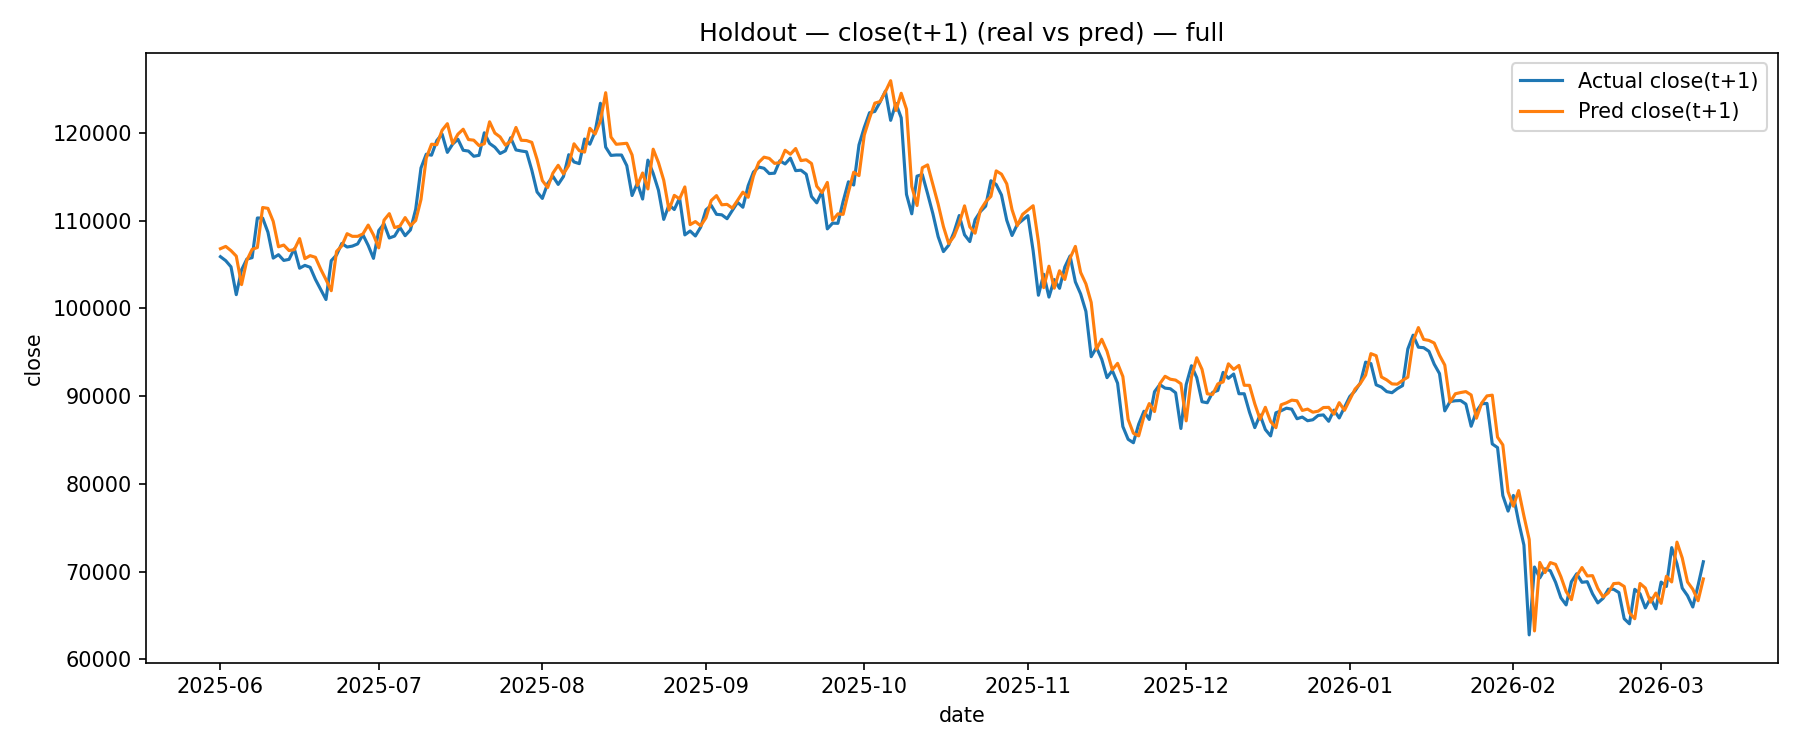

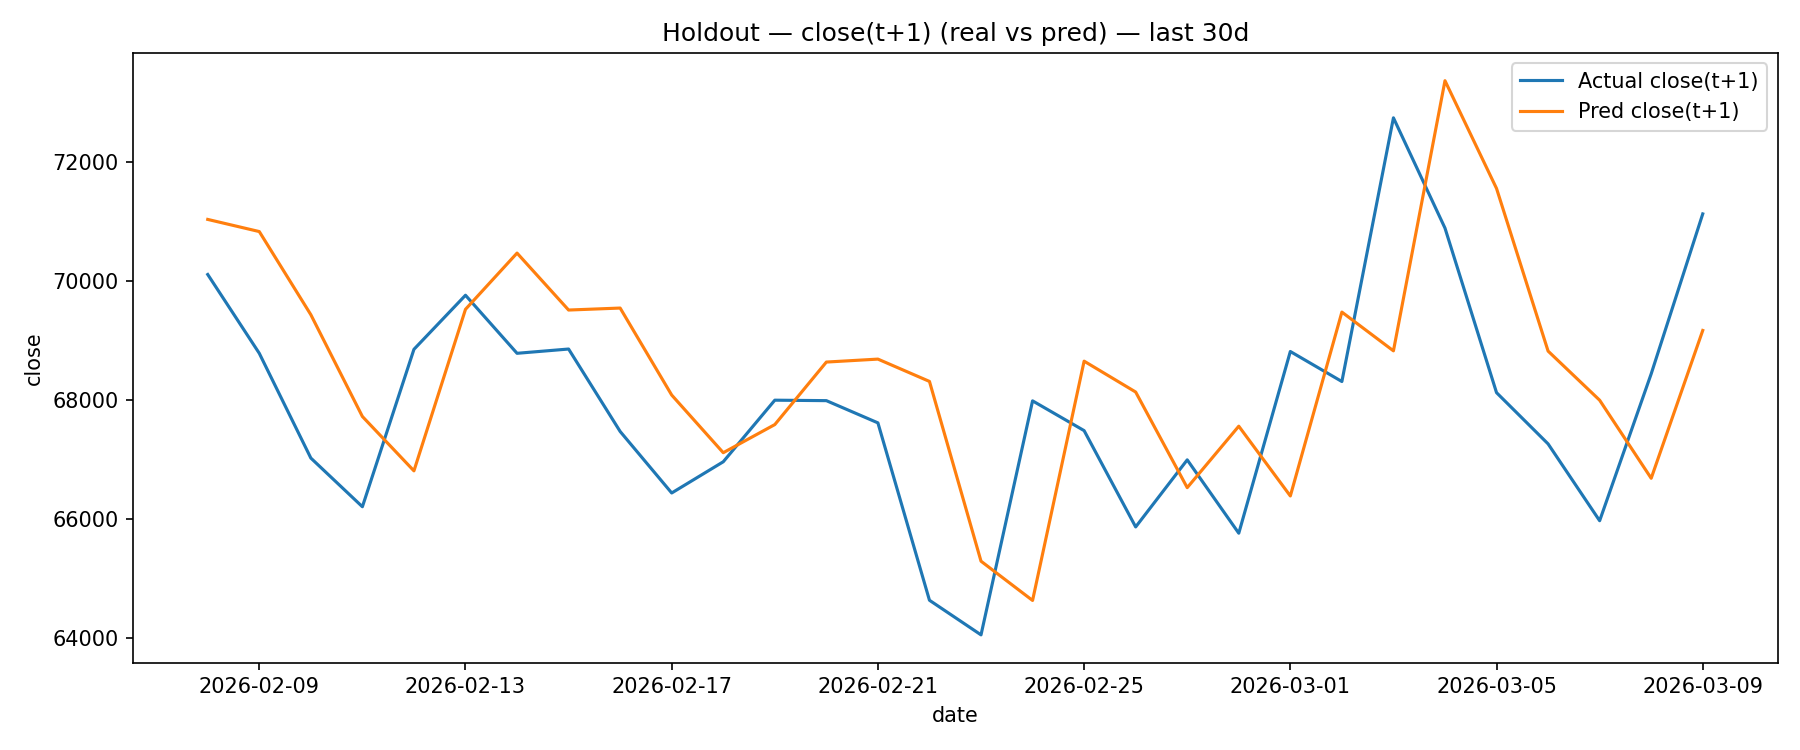

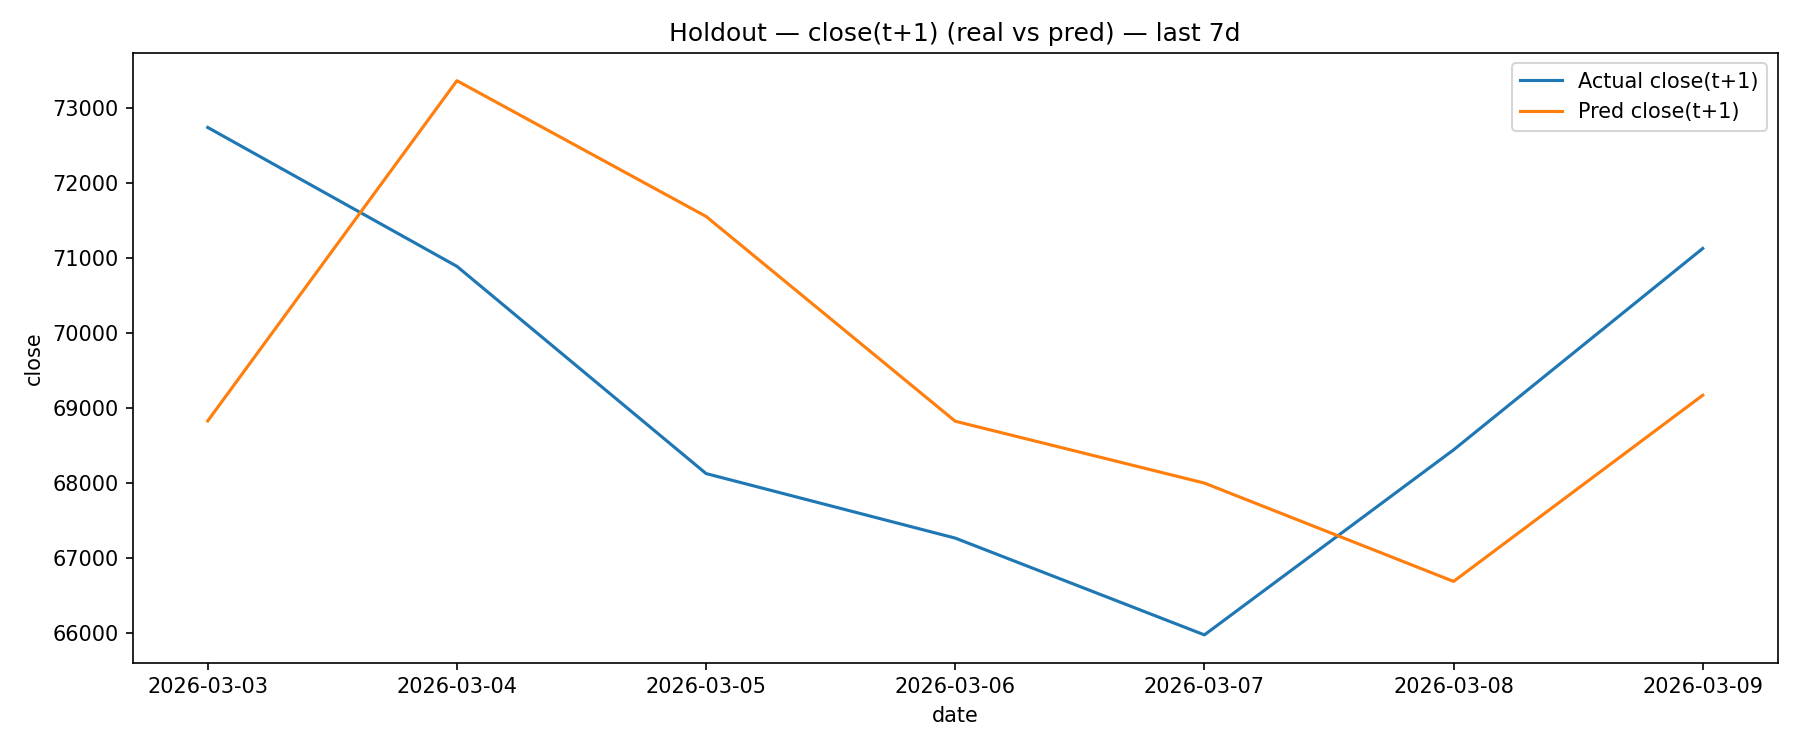

('data/_experiments/close/T3_01_transformer_gru/full/20260312_014002/fig_holdout_full.png',
 'data/_experiments/close/T3_01_transformer_gru/full/20260312_014002/fig_holdout_last30d.png',
 'data/_experiments/close/T3_01_transformer_gru/full/20260312_014002/fig_holdout_last7d.png')

In [11]:
def plot_holdout_close(pred: pd.DataFrame, title: str, out_path: Path, last_n: int | None = None) -> None:
    d = pred.copy()
    if last_n is not None:
        d = d.tail(last_n)

    plt.figure(figsize=(12, 5))
    plt.plot(d["date"], d["y_true_close_t1"], label="Actual close(t+1)")
    plt.plot(d["date"], d["y_pred_close_t1"], label="Pred close(t+1)")
    plt.title(title)
    plt.xlabel("date")
    plt.ylabel("close")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    display(Image(filename=str(out_path)))
    plt.close()


fig_full = OUT_DIR / "fig_holdout_full.png"
fig_last30 = OUT_DIR / "fig_holdout_last30d.png"
fig_last7 = OUT_DIR / "fig_holdout_last7d.png"

plot_holdout_close(pred_holdout, "Holdout — close(t+1) (real vs pred) — full", fig_full, last_n=None)
plot_holdout_close(pred_holdout, "Holdout — close(t+1) (real vs pred) — last 30d", fig_last30, last_n=30)
plot_holdout_close(pred_holdout, "Holdout — close(t+1) (real vs pred) — last 7d", fig_last7, last_n=7)

to_relative(fig_full, PROJECT_ROOT), to_relative(fig_last30, PROJECT_ROOT), to_relative(fig_last7, PROJECT_ROOT)

## 12) Figura timeline folds + holdout

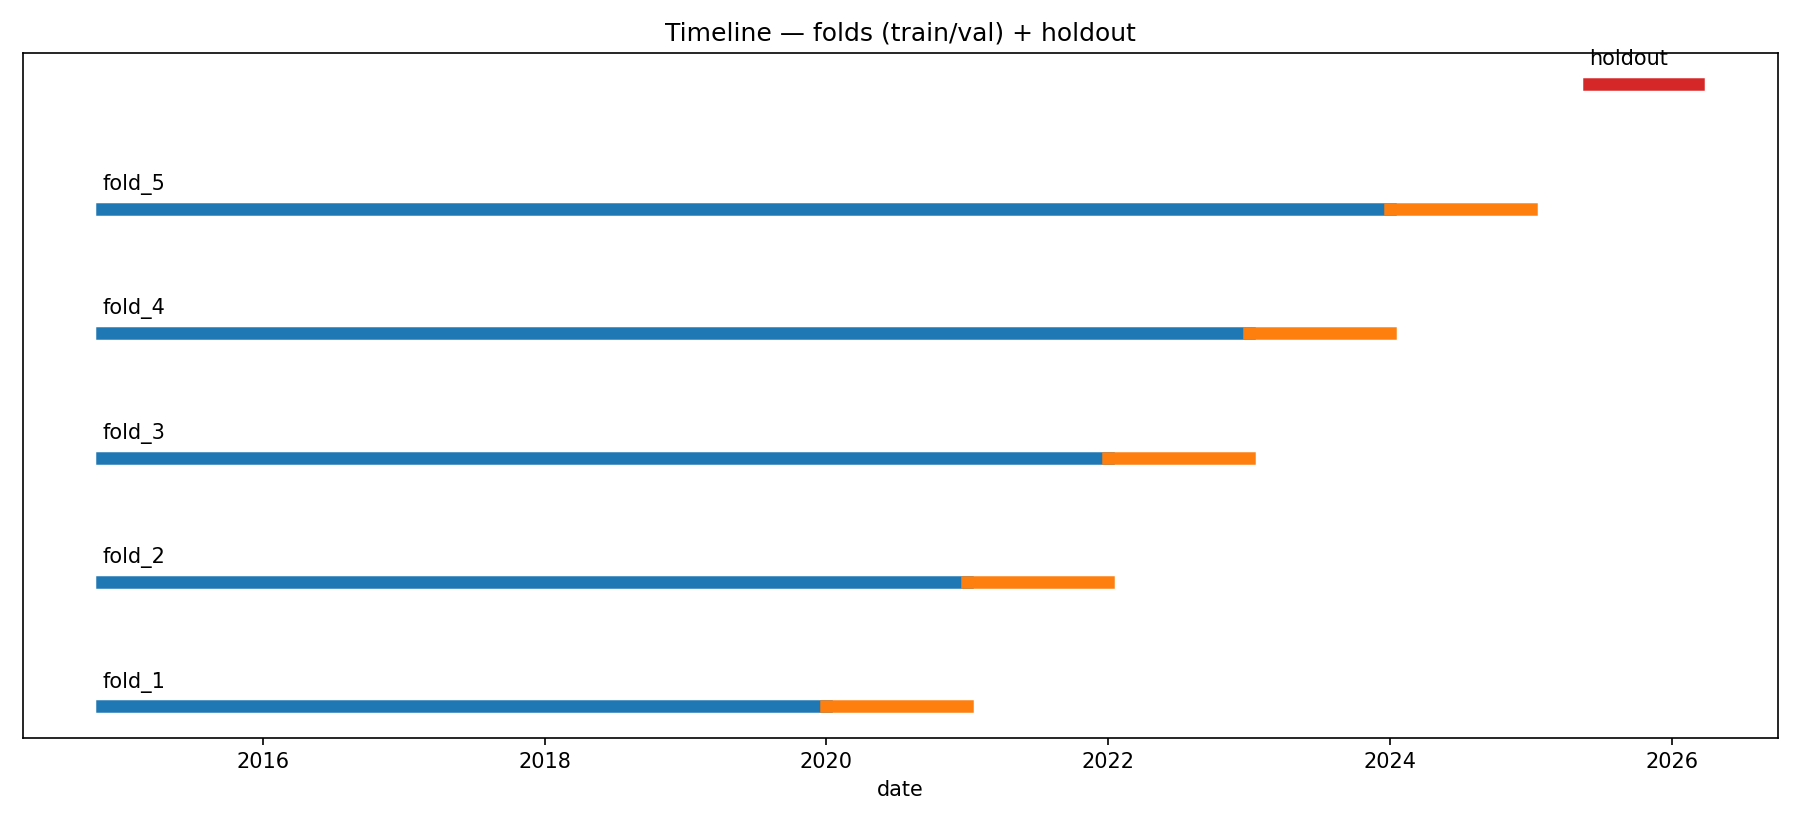

'data/_experiments/close/T3_01_transformer_gru/full/20260312_014002/fig_timeline_folds_holdout.png'

In [12]:
def plot_timeline(folds: list[Period], holdout_start: pd.Timestamp, holdout_end: pd.Timestamp, out_path: Path) -> None:
    plt.figure(figsize=(12, 3 + 0.5 * len(folds)))
    y = 0
    for p in folds:
        plt.plot([p.train_start, p.train_end], [y, y], color="#1f77b4", linewidth=6)
        plt.plot([p.val_start, p.val_end], [y, y], color="#ff7f0e", linewidth=6)
        plt.text(p.train_start, y + 0.15, p.name)
        y += 1

    plt.plot([holdout_start, holdout_end], [y, y], color="#d62728", linewidth=6)
    plt.text(holdout_start, y + 0.15, "holdout")

    plt.yticks([])
    plt.title("Timeline — folds (train/val) + holdout")
    plt.xlabel("date")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    display(Image(filename=str(out_path)))
    plt.close()


fig_timeline = OUT_DIR / "fig_timeline_folds_holdout.png"
plot_timeline(folds, holdout_start, holdout_end, fig_timeline)
to_relative(fig_timeline, PROJECT_ROOT)

## 13) Curva de loss (dev training)

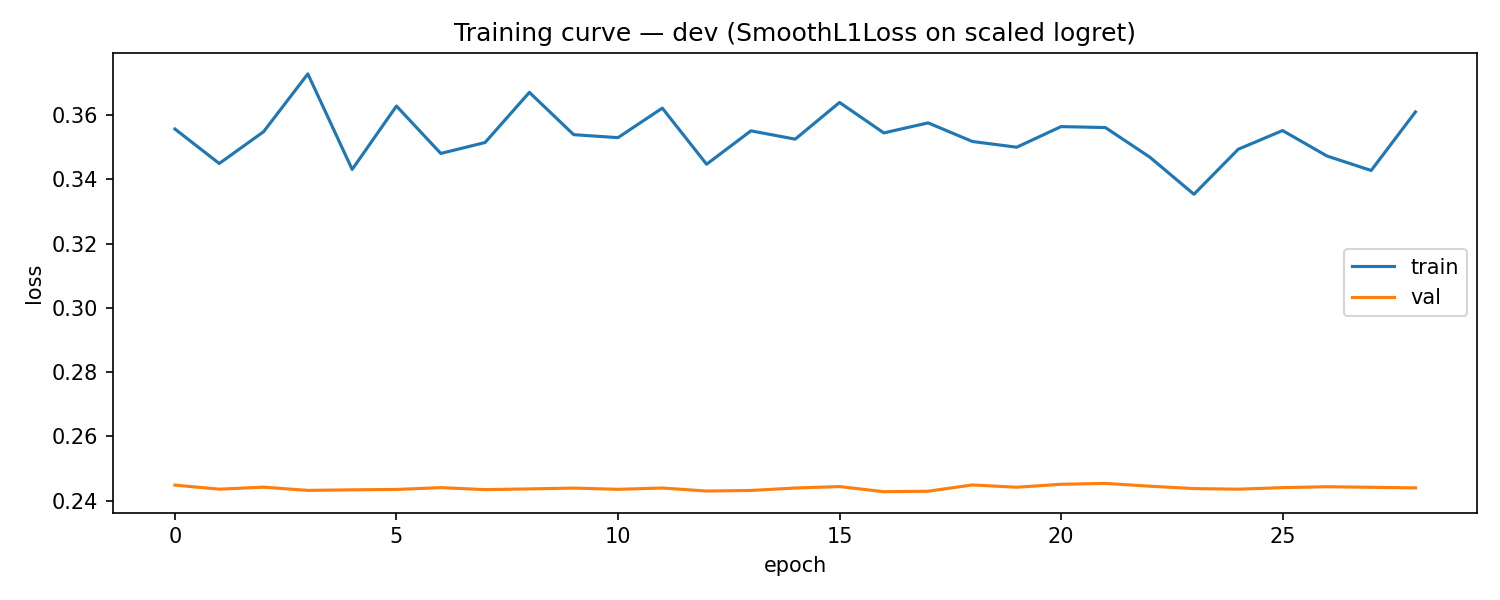

'data/_experiments/close/T3_01_transformer_gru/full/20260312_014002/fig_loss_dev.png'

In [13]:
fig_loss = OUT_DIR / "fig_loss_dev.png"

plt.figure(figsize=(10, 4))
plt.plot(history_dev["train_loss"], label="train")
plt.plot(history_dev["val_loss"], label="val")
plt.title("Training curve — dev (SmoothL1Loss on scaled logret)")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()
plt.savefig(fig_loss, dpi=150)
display(Image(filename=str(fig_loss)))
plt.close()

to_relative(fig_loss, PROJECT_ROOT)